### Block 1 - Comments and Imports ###
* **90 $^\circ$ Phase Advance:** Means the particle completes exactly 1/4 of an oscillation cycle as it passes through a single FODO cell. In a circular arc, 4 such cells would result in a full $2\pi$ phase advance. The $90^\circ$ choice can minimise depolarization, where the particles spin precesses in sync with the magnetic field it encounters.


* **Three-fold Periodicity:** The ring has three identical sections. This symmetry helps simplify the mathematical solution for the 'closed orbit' and manage resonance effects.


* **DS (Dispersion Suppressor) Bend Length:** The DS is a specific arrangement of magnets that brings disersion to zero before the beam enters a straight section (where experiments or injections happen).


* **Triplet Waists:** A triplet is a set of three quadrupoles used to focus the beam very tightly in the horizontal and vertical planes simultaneously. A 'waist' is the point of minimum beams size. 

In [1]:
"""
Worked on around January 2025

Another polarizer ring design attempt based 90 degrees phase FODO cells in arcs
 - Again three fold periodicity (similar geometry than damping ring in same 
   tunnel?)
 - Adjustement of DS bend length to improve optics
 - "Only" two "triplet waists" per straight section
 - No wigglers (and routines to generate them removed)
"""

import xtrack as xt
import numpy as np
import os
import matplotlib.pyplot  as plt
import matplotlib.patches as patches

### Block 2 - Environment, Parameters, and Cell Structures ###
1. **Variable Definitions**
* `l_cell`/`l_bend`: Lengths in metres

* `kQFarc`/`kQDarc`: Quadrupole strengths

* `hBarc`: Curvature ($\rho^{-1}$).

2. **Magnetic Element Construction**
* Dipoles are using `k0_from_h=True` which tells `Xtrack` to calculate the bending field based on the design curvature.

* Edge angles: `edge_entry_angle='hBarc*l_bend/2'` describes a 'sector bend' or specific edge focusing. By angling the entrance/exit of the magnet, additional focusing is provided to the beam.

* The code defines different variations of quadrupoles (Arc, Triplet, DS) because each ring requires different focusing strengths to keep the beam stable.

In [6]:
# %% create environment, parameters and first simple cells & structures

pdr = xt.Environment()
pdr.particle_ref = xt.Particles(kinetic_energy0=2.86e9, mass0 = xt.ELECTRON_MASS_EV)

E0 = 2.86e9; VRF = 2.000e6 # beam energy in eV and RF voltage (1 cavity) in V

pdr.vars({'l_cell': 3.40,'l_bend': 0.40,'l_bendDS': 0.55,'dl_noben': 0.25, 'l_quad': 0.30,
  'l_drift': '(l_cell - 2*l_bend - 2*l_quad)/4.','dl_drift': -0.15, 'dl_trans': 0.00,
  'l_doub':  0.25, 'l_tripl': 3.00, 'l_trips': 0.40})

pdr.vars({'N_cells_S': 8,'hBarc' : '6.283185307/(6*(2*N_cells_S*l_bend + l_bendDS))',
  'kQFarc': 2.9478, 'kQDarc':-2.9231,'kQFarcM': 2.8846, 'kQDarcM':-2.7567, 
  'kQFDS': 2.8042, 'kQDDS':-2.2858, 'kQFDoub': 3.9170, 'kQDDoub':-2.5190, 
  'kQFtr': 4.4429, 'kQDtr':-2.4723 } )

U0 = (0.88463e-31)*E0**4*(2.*np.pi)/(6*(2*pdr['N_cells_S']*pdr['l_bend'] + pdr['l_bendDS']) )

pdr.new('Bend', xt.Bend, length='l_bend', angle='hBarc*l_bend', k0_from_h=True, 
         edge_entry_angle='hBarc*l_bend/2', edge_exit_angle='hBarc*l_bend/2')
pdr.new('QFarc',  xt.Quadrupole, length='l_quad',    k1='kQFarc' )
pdr.new('QFarcH', xt.Quadrupole, length='l_quad/2.', k1='kQFarc' )
pdr.new('Drarc',  xt.Drift,      length='l_drift' )
pdr.new('DrarcS', xt.Drift,      length='l_drift + dl_drift' )
pdr.new('QDarc',  xt.Quadrupole, length='l_quad',    k1='kQDarc' )
pdr.new('QFarcM', xt.Quadrupole, length='l_quad',    k1='kQFarcM' )
pdr.new('QDarcM', xt.Quadrupole, length='l_quad',    k1='kQDarcM' )
pdr.new('BendDS', xt.Bend, length='l_bendDS', angle='hBarc*l_bendDS', k0_from_h=True, 
         edge_entry_angle='hBarc*l_bendDS/2', edge_exit_angle='hBarc*l_bendDS/2')
pdr.new('QFDS',   xt.Quadrupole, length='l_quad',    k1='kQFDS' )
pdr.new('QDDS',   xt.Quadrupole, length='l_quad',    k1='kQDDS' )
pdr.new('DrDSL',  xt.Drift,      length='2*l_drift + l_bend + dl_noben' )
pdr.new('DrTrans',xt.Drift,      length='l_drift + dl_trans' )
pdr.new('QFDoub', xt.Quadrupole, length='l_quad',    k1='kQFDoub' )
pdr.new('QDDoub', xt.Quadrupole, length='l_quad',    k1='kQDDoub' )
pdr.new('DrDoub', xt.Drift,      length='l_doub' )

pdr.new('QFtr',    xt.Quadrupole, length='l_quad',    k1='kQFtr' )
pdr.new('QFtrH',   xt.Quadrupole, length='l_quad/2.', k1='kQFtr' )
pdr.new('QDtr',    xt.Quadrupole, length='l_quad',    k1='kQDtr' )
pdr.new('QDtrH',   xt.Quadrupole, length='l_quad',    k1='kQDtr' )
pdr.new('DrTripl', xt.Drift,      length='l_tripl' )
pdr.new('DrTrips', xt.Drift,      length='l_trips' )


'DrTrips'

### Block 3 - Lattice Assembly ###
**`cell_arcS` (Absolute Positioning)**

* Uses `at which places the magnet at specific coordinates from the start of the cell

**`cell_arc` (Sequential Positioning)**

* Uses `pdr.place('Drarc')` which places the elements one after another.

* It starts and ends with `QFarcH` (Half length QF) . This is to create a symmetric cell. Sticking the two cells together it forms a full quadrupole.

**`cell_tr` (The Triplet)**

* A triplet is used to create low-beta points - a spot where the beam is focused to a tiny point.

* `xt.Marker` is a virtual element without a magnetic field. It acts as a landmark where beam properties can be recorded (e.g. width or position)

Quadrupole strengths have been matched so that the phase advance across one cell arc is exactly $\pi/2$. This ensures that if the particle is out of alignment, it will return to its original position after exactly 4 cells, preventing the beam from drifting away and hitting the pipe wall.



Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


3.4
3.3999999999999995
4.7


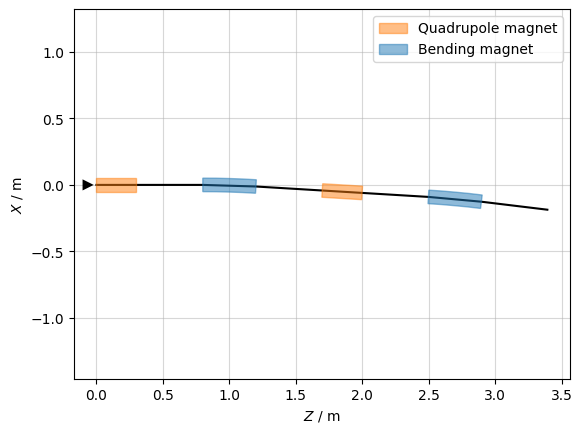

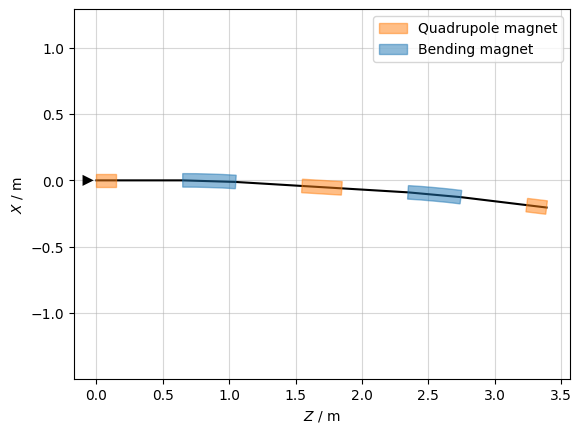

In [7]:
# just an arc cell
cell_arcS = pdr.new_line( length='l_cell', 
    components =[ 
    pdr.new('QF_cell_arc',    'QFarc',at='0*l_drift + 0.5*l_quad + 0.0*l_bend'),
    pdr.new('Bend1_cell_arc', 'Bend', at='1*l_drift + 1.0*l_quad + 0.5*l_bend'),
    pdr.new('QD_cell_arc',    'QDarc',at='2*l_drift + 1.5*l_quad + 1.0*l_bend'),
    pdr.new('Bend2_cell_arc', 'Bend', at='3*l_drift + 2.0*l_quad + 1.5*l_bend'),
    ])
cell_arcS.survey().plot()
print(cell_arcS.get_length())
cell_arc = pdr.new_line( components = [ 
   pdr.new('QF_cell_arcH1',  'QFarcH' ), pdr.place( 'Drarc' ),
   pdr.new('Bend1_cell_arcH','Bend' ),   pdr.place( 'Drarc' ),
   pdr.new('QD_cell_arcH',   'QDarc' ),  pdr.place( 'Drarc' ),
   pdr.new('Bend2_cell_arcH','Bend' ),   pdr.place( 'Drarc' ),
   pdr.new('QF_cell_arcH2',  'QFarcH' ), 
   ])
cell_arc.survey().plot()
print(cell_arc.get_length())
# triplet starting with 
cell_tr = pdr.new_line(
    components = [
    pdr.new('QF_cell_trH1', 'QFtrH',    at='0*l_trips + 0.25*l_quad + 0.0*l_tripl'),
    pdr.new('QD_cell_tr1',  'QDtr',     at='1*l_trips + 1.00*l_quad + 0.0*l_tripl'),
    pdr.new('Mkr_cell_tr',   xt.Marker, at='1*l_trips + 1.50*l_quad + 0.5*l_tripl'),
    pdr.new('QD_cell_tr2',  'QDtr',     at='1*l_trips + 2.00*l_quad + 1.0*l_tripl'),
    pdr.new('QF_cell_trH2', 'QFtrH',    at='2*l_trips + 2.75*l_quad + 1.0*l_tripl')
    ])

print(cell_tr.get_length())

### Block 4 - Defining routines ###

**`makesextant`**
* A sextant is 1/6 of the ring.

The function is adding Dispersion Suppressors and Doublets.

* The DS magnets are tuned to force dispersion to zero so that the straight sections are achromatic.

* The doublet is used for matching the beam optics from the arc into the straight section.

* Symmetry (`fall=='symm'`): Designed with mirror symmetry which simplifies the maths for the Twiss parameters.

**`addSketchBL`**
* Accelerator optics visuals

* Creates a lattice and optics plot to verify the design.

* Beta functions are plotted as solid/dashed lines

* Quadrupoles are plotted above or below the line depending on their strengths and whether they are focusing or defocusing.

**`SpuckParsAus`**
* Calculates circumference, revolution time, and tune.

**"Slicing" the magnet**
* Xtrack treats magnets as thick elements.

* To get a smooth curve for the $\beta$-functions, the magnets are cut into slices. Without this, only beam properties at the start and end of the magnet could be calculated.

In [22]:
# %% define a couple of routines
# routine for a sextant starting with F quad at arc center
def makesextant ( name, fall ):
    comps = [ ]
    for ind in range( pdr['N_cells_S'] - 1 ):  # regular arc cells
       comps = comps + [ pdr.place('Drarc'), pdr.new('Bend1_' + name + str(ind+1), 'Bend')]
       comps = comps + [ pdr.place('Drarc'), pdr.new('QDA_' + name + str(ind+1), 'QDarc')]
       comps = comps + [ pdr.place('Drarc'), pdr.new('Bend2_' + name + str(ind+1), 'Bend')]
       comps = comps + [ pdr.place('Drarc'), pdr.new('QFA_' + name + str(ind), 'QFarc')]
    # Replace last QF and add last arc cell (matching quads) "by hand"
    comps[-1] = pdr.new('QFAM' + name + str(pdr['N_cells_S']), 'QFarcM' )
    comps = comps + [pdr.place('DrarcS'),pdr.new('Bend1_' + name + str(pdr['N_cells_S']), 'Bend')]
    comps = comps + [pdr.place('Drarc'), pdr.new('QDAM_' + name + str(pdr['N_cells_S']), 'QDarcM')]
    comps = comps + [pdr.place('Drarc'), pdr.new('Bend2_' + name + str(pdr['N_cells_S']), 'Bend')]
    # Add dispersion suppressor
    comps = comps + [pdr.place('Drarc'), pdr.new('QFDS_' + name, 'QFDS') ]
    comps = comps + [pdr.place('DrDSL'), pdr.new('QDDS_' + name, 'QDDS') ]
    comps = comps + [pdr.place('Drarc'), pdr.new('BendDS_' + name, 'BendDS')]
    # Add doublet matching 
    comps = comps + [pdr.place('DrTrans'), pdr.new('QFDoub_' + name, 'QFDoub')]
    comps = comps + [pdr.place('DrDoub'), pdr.new('QDDoub_' + name, 'QDDoub')]   
    comps = comps + [pdr.place('DrTripl'), pdr.new('QDTrip_' + name + '1', 'QDtr')]  
    if fall == 'symm':
       comps = [ pdr.new('QFA_' + name + 'CH', 'QFarcH' ) ] + comps
       comps = comps + [ pdr.place('DrTrips'), pdr.new('QFTripC_' + name + '2H', 'QFtrH')]
    elif fall == 'right':
       comps = [ pdr.new('QFA_' + name + 'C', 'QFarc'  ) ] + comps + [ pdr.place('DrTrips') ]
    elif fall == 'left':
       comps = comps + [pdr.place('DrTrips'), pdr.new('QFTripC_' + name + '2', 'QFtr') ]
       comps = list( reversed(comps) )
    else:
       print( '=====> choice for sextant version incorrect <=====' )
       quit()
    return pdr.new_line( components = comps )

# Routine may evolve to generic lattice plot routine
def addSketchBL( acc_tw, acc, lims, limy1, limy2, scK1 ):
    fig, ax = plt.subplots( 3, 1, figsize=(12, 8), height_ratios=(1.8, 4, 3) )
    axl, axp, axt = ax
    axp.sharex( axl )
    fig.subplots_adjust( hspace=0.0, top=1.0, bottom=0.0, left=.1 )

    axp.set_xlabel( 'Position s [m]' )
    axp.set_ylim( limy1 )
    axp.set_ylabel( r'$\beta_x$, $\beta_y$ [m]' )
      
    indm = int( np.array([(np.sign(lims[-1]-x) + 1)/2 for x in acc_tw.s ]).sum() )
    axp.plot( acc_tw.s[:indm], acc_tw.betx[:indm], color='black', linestyle=(0, (10, 0)) )
    axp.plot( acc_tw.s[:indm], acc_tw.bety[:indm], color='black', linestyle=(0, (6, 4)) )
    axp2 = axp.twinx()
    axp2.set_ylim( limy2 )
    axp2.set_ylabel( r'$D_x$, $D_y$ [m]' )
    axp2.plot( acc_tw.s[:indm], acc_tw.dx[:indm], color='black', linestyle=(0, (5, 3, 1, 3)) )
    axp2.plot( acc_tw.s[:indm], acc_tw.dy[:indm] )
    axp.set_xlim( lims )
    
    axl.set_ylim( -.30, 1.00 )
    axl.axis( 'off' )
    tab_pan = acc.get_table(attr=True).to_pandas()
    for ind in range( len(tab_pan.T.columns) -1 ):
        if tab_pan['element_type'][ind].find('Drift') >= 0:
           axl.plot( [tab_pan['s'][ind], tab_pan['s'][ind+1]], [0, 0], color='black' )
        if tab_pan['element_type'][ind].find('Bend') >= 0:
           axl.add_patch( patches.Rectangle( (tab_pan['s'][ind], -0.08), 
               tab_pan['s'][ind+1] - tab_pan['s'][ind], 0.16, fill=True, color='tab:blue' ) ) 
        if tab_pan['element_type'][ind].find('Quad') >= 0:
           kstr = scK1*tab_pan['k1l'][ind]/tab_pan['length'][ind]
           axl.add_patch( patches.Rectangle( (tab_pan['s'][ind], min(0.0, kstr)),
               tab_pan['s'][ind+1] - tab_pan['s'][ind], abs(kstr), fill=True, color='tab:orange' ) )        
    axp.plot( [acc.get_length(), acc.get_length()], limy1, color='black', 
              linestyle=(0, (8, 8)), linewidth=.5 )

    axt.axis( 'off' )
    axt.set_xlim( -.3, 3.8 ); axt.set_ylim( 0, 1 )
    return axt

# Routine generating graphical and text output describing the ring    
def SpuckParsAus( acc_tw, acc, lims, limy1, limy2, scK1, grname='NoGraph' ):
    axt = addSketchBL( acc_tw, acc, lims, limy1, limy2, scK1 )
    axt.text( 0.0, .7, f'C ={3*acc_tw.circumference:8.4f} m', horizontalalignment='left' )
    axt.text( 1.0, .7, f'T ={3e6*acc_tw.T_rev0:8.4f} us', horizontalalignment='left')
    axt.text( 2.0, .7, r'($Q_x$, $Q_y$)' + f' = ({3*acc_tw.qx:9.5f}, {3*acc_tw.qy:9.5f})', 
        horizontalalignment='left')
    pos=0
    for item in pdr.vars.keys()[2:]:
       print( "'" + item + f"': {pdr[item]:8.4f}," )
       axt.text( pos%4 , .6 - .1*int( pos/4 ),
          "'" + item + f"': {pdr[item]:8.4f},", horizontalalignment='left' )
       pos += 1
    if grname != 'NoGraph': 
       if grname in os.listdir( '/home/mwatson/Documents/laughing-octo-bassoon'):
          print( ' Error: file ' + grname + ' exists <<<<<<<<<<<================' )
       else:
          plt.savefig( '/home/mwatson/Documents/laughing-octo-bassoon' + grname )
    tab_pan = acc.get_table(attr=True).to_pandas()
    print('  Name        Type      L(m)     sin(m)   sout(m)  driftl  driftr    k1(1/m^2)')
    for ind in range( len(tab_pan.T.columns) - 1 ):
       eltyp = tab_pan['element_type'][ind]
       if eltyp.find('Drift') < 0:
          elnam = tab_pan['name'][ind]
          if ind < 1: sin = '  0.0000'
          else: sin = f"{tab_pan['length'][ind-1]:8.4f}"         
          k1expr = pdr.element_refs[elnam].k1._expr
          if k1expr == None: k1expr = ' None'
          else: k1expr = str(k1expr)[5:-1]
          print(  "  " + elnam.ljust( 12 ) + eltyp.ljust(12)[:8] + f" {tab_pan['length'][ind]:7.4f} " + 
               f"{tab_pan['s'][ind]:8.4f} {tab_pan['s'][ind+1]:8.4f} " + sin +
               f"{tab_pan['length'][ind+1]:8.4f} " + k1expr.ljust(9) + 
               f"= {tab_pan['k1l'][ind]/max(tab_pan['length'][ind],1e-6):7.4f}  " )

''' # remainder from testings of the routines
try: # error handling structure to generate arc1R and period only when not yet done
    arc1RFlag
except NameError:
    arc1R = makesextant( 'xR', 'symm' )
    period = makesextant( 'PR', 'symm') + (-makesextant( 'PL', 'symm'))
    period_sliced = period.select()
    print( np.linspace(.05, period_sliced.get_length()-.05, 
                            int( period_sliced.get_length()/.05 - .5 ) ) )
    period_sliced.cut_at_s( np.linspace(.05, period_sliced.get_length()-.05, 
                            int( period_sliced.get_length()/.05 - .5 ) ) )
    arc1RFlag = True

addSketchBL( period_sliced.twiss(method='4d'), arc1R, (0., 38.), (0., 10.), (0., 1.), .08 )
SpuckParsAus( period_sliced.twiss(method='4d'), arc1R, (0., 38.), (0., 10.), (0., 1.), .08, 'NoGraph' )
'''

" # remainder from testings of the routines\ntry: # error handling structure to generate arc1R and period only when not yet done\n    arc1RFlag\nexcept NameError:\n    arc1R = makesextant( 'xR', 'symm' )\n    period = makesextant( 'PR', 'symm') + (-makesextant( 'PL', 'symm'))\n    period_sliced = period.select()\n    print( np.linspace(.05, period_sliced.get_length()-.05, \n                            int( period_sliced.get_length()/.05 - .5 ) ) )\n    period_sliced.cut_at_s( np.linspace(.05, period_sliced.get_length()-.05, \n                            int( period_sliced.get_length()/.05 - .5 ) ) )\n    arc1RFlag = True\n\naddSketchBL( period_sliced.twiss(method='4d'), arc1R, (0., 38.), (0., 10.), (0., 1.), .08 )\nSpuckParsAus( period_sliced.twiss(method='4d'), arc1R, (0., 38.), (0., 10.), (0., 1.), .08, 'NoGraph' )\n"

### Block 5 - Ring Assembly and RF Inclusion ###
* Completes the ring and adds energy compensation

* Adds the sextants together to form the full ring. It calculates the RF Cavity frequency needed to match the revolution time and adds the cavity to the ring to restore energy lost via synchrotron radiation.

**The synchronous phase `lag`**

* $\text{lag}\propto \pi - \arcsin{(U_0/V_{RF})}$

* The particles must arrive at the cavity when the voltage is exactly right to replace the energy lost. This specific timing creates a stable bucket in the longitudinal plane,

* `fRF=fRev*round(4e8/fRev)` ensures the RF frequency is an exact integer multiple of the revolution frequency, allowing multiple bunches to circulate simultaneously.

* `1/ring_tw.damping_constants_turns[1]` is the damping time.

* `spin_t_pol_buildup_s` is the polarization time

* `-makesextant` (Lattice reversal)  - The minus operator on a line object reverses the order. Used to create mirror symmetry for the closed ring.

* `cut_at_s` slices the magnets.


Slicing line: 100%|██████████| 154/154 [00:00<00:00, 3424.25it/s]


'l_cell':   3.4000,
'l_bend':   0.4000,
'l_bendDS':   0.5500,
'dl_noben':   0.2500,
'l_quad':   0.3000,
'l_drift':   0.5000,
'dl_drift':  -0.1500,
'dl_trans':   0.0000,
'l_doub':   0.2500,
'l_tripl':   3.0000,
'l_trips':   0.4000,
'N_cells_S':   8.0000,
'hBarc':   0.1507,
'kQFarc':   2.9478,
'kQDarc':  -2.9231,
'kQFarcM':   2.8846,
'kQDarcM':  -2.7567,
'kQFDS':   2.8042,
'kQDDS':  -2.2858,
'kQFDoub':   3.9170,
'kQDDoub':  -2.5190,
'kQFtr':   4.4429,
'kQDtr':  -2.4723,
  Name        Type      L(m)     sin(m)   sout(m)  driftl  driftr    k1(1/m^2)
  QFA_xRCH    Quadrupo  0.1500   0.0000   0.1500   0.0000  0.5000 'kQFarc' =  2.9478  
  Bend1_xR1   Bend      0.4000   0.6500   1.0500   0.5000  0.5000  None    =  0.0000  
  QDA_xR1     Quadrupo  0.3000   1.5500   1.8500   0.5000  0.5000 'kQDarc' = -2.9231  
  Bend2_xR1   Bend      0.4000   2.3500   2.7500   0.5000  0.5000  None    =  0.0000  
  QFA_xR0     Quadrupo  0.3000   3.2500   3.5500   0.5000  0.5000 'kQFarc' =  2.9478  
  Bend1_xR2  

Slicing line: 100%|██████████| 456/456 [00:00<00:00, 232676.72it/s]


Horizontal Chromaticity (dqx): -19.8649
Vertical Chromaticity (dqy):   -17.8166
Max Betx: 8.38 m
Max Bety: 8.16 m


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.



Approximatif harmonics  283.00000 and fRF =399440980.50978
  Length of short drifts:   0.500 m
=>Circumference 212.4000 and revolution  0.70849 us
  Energy loss per turn from me  891804.40 and twiss   892439.29 and diff     634.90
  Vertical damping time   6410.541 and   6409.400 turns
  Working point  15.30013 and  14.40008
  Equilibrium emmittances 2.930e-08, 2.631e-55 and 1.295e-05
  Equilibrium polarization 0.92376 and time     767.02 s


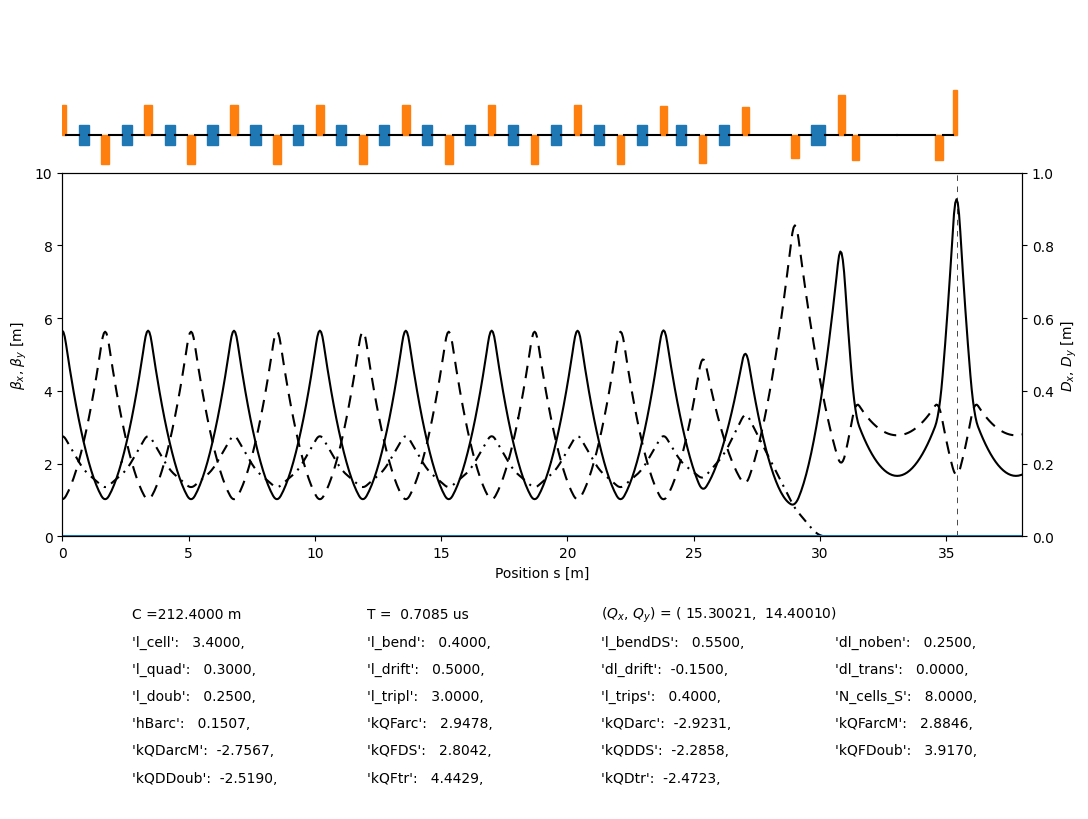

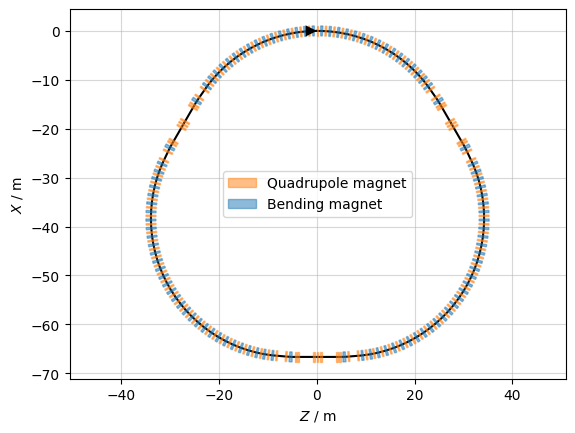

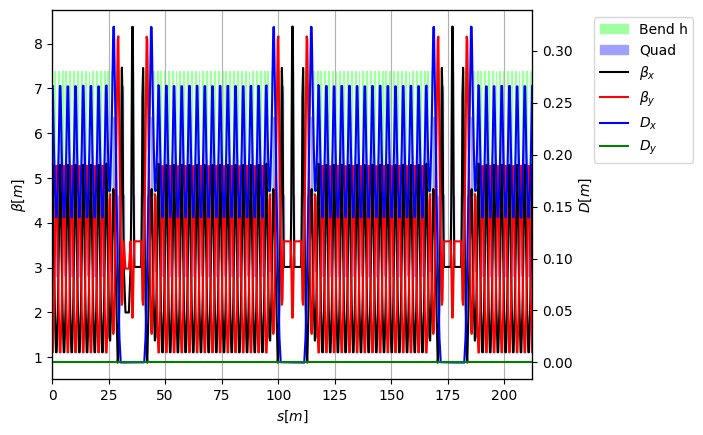

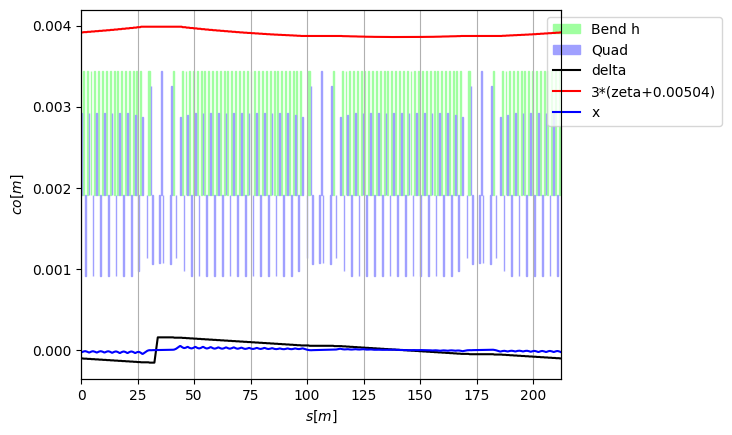

In [23]:
# %% Generate structures - execute only once otherwise resulting in errors
# Half-period from the arc center (middle of quad) to the straight (middle of arc) center
arc1R = makesextant( 'xR', 'symm' )
arc1R_sliced = arc1R.select()
arc1R_sliced.cut_at_s( np.linspace(.05, arc1R.get_length()-.05, int(arc1R.get_length()/.05-.5)) )
arc1R.insert( pdr.new('CtrS1_xR1', xt.Marker ), at='(l_tripl+l_quad)/2', from_='QDDoub_xR' )

# One period from center of arc to center of arc
period = makesextant( 'PR', 'symm') + ( -makesextant( 'PL', 'symm') )
period_sliced = period.select()
period_sliced.cut_at_s( np.linspace(.05, period.get_length()-.05, int(period.get_length()/.05-.5)) )
SpuckParsAus( period_sliced.twiss(method='4d'), arc1R, (0., 38.), (0., 10.), (0., 1.), .08, "Standard.pdf" )

# Full ring without X-poles, RF and wigglers
ring  = makesextant( '1R', 'right') + makesextant( '2L', 'left') + makesextant( '2R', 'right') + makesextant( '3L', 'left') + makesextant( '3R', 'right') + makesextant( '1L', 'left')
fRev = 1./(ring.twiss(method='4d').T_rev0)
fRF  = fRev*round(4.e8/fRev)  # at integer harmonics and close to 400 MHz
pdr.new('RFCav',  xt.Cavity, length=1.5, frequency=fRF, voltage=VRF, 
        lag=(180/np.pi)*(np.pi - np.arcsin(U0/VRF)) - 1.8 ) 
ring.insert( pdr.new('RFCav_1', 'RFCav'), at='(l_tripl+l_quad)/2', from_='QDDoub_1R' )
ring.configure_radiation(model='mean')
ring.configure_bend_model(edge='full')
ring_tw=ring.twiss(method='6d', radiation_integrals=True, eneloss_and_damping=True,
                   spin=True, polarization=True )
print(f"Horizontal Chromaticity (dqx): {ring_tw.dqx:.4f}")
print(f"Vertical Chromaticity (dqy):   {ring_tw.dqy:.4f}")
print(f"Max Betx: {max(ring_tw.betx):.2f} m")
print(f"Max Bety: {max(ring_tw.bety):.2f} m")

ring.survey().plot()
ring_tw.plot()
ring_tw.plot('delta 3*(zeta+0.00504) x')

print( f'\nApproximatif harmonics {fRF/fRev:10.5f} and fRF ={fRF:8.5f}' )
# print( ring_tw.keys() )
print( f"  Length of short drifts: {pdr['l_drift']:7.3f} m" )
# print( ring_tw.keys() )
print( f'=>Circumference {ring_tw.circumference:8.4f} and revolution {1e6*ring_tw.T_rev0:8.5f} us' )
print( f'  Energy loss per turn from me {U0:10.2f} and twiss' + 
       f'  {ring_tw.eneloss_turn:10.2f} and diff {ring_tw.eneloss_turn-U0:10.2f}' )
print( f'  Vertical damping time {1/ring_tw.damping_constants_turns[1]:10.3f} and {2*E0/ring_tw.eneloss_turn:10.3f} turns' )
print( f'  Working point{ring_tw.qx:10.5f} and{ring_tw.qy:10.5f}')
print( f'  Equilibrium emmittances{ring_tw.eq_gemitt_x:10.3e},{ring_tw.eq_gemitt_y:10.3e} and{ring_tw.eq_gemitt_zeta:10.3e}'  )
print( f'  Equilibrium polarization{ring_tw.spin_polarization_eq:8.5f} and time {ring_tw.spin_t_pol_buildup_s:10.2f} s')


### Block 6 - Optics Matching ###
* Fine-tunes the magnet strengths to ensure beam stability

* Uses `run_jacobian` to automatically adjust quadrupole strengths. It matches the lattice so that the phase advance is exactly 90 $^\circ$ and dispersion is cancelled in the straight sections.

In [24]:
# %% Routine for several matchings in a row for 90 degrees arc cells and given tunes

# Matching of arc cell
cell_arc_opt = cell_arc.match( method='4d', solve=False, verbose=False,
    vary=[
        xt.VaryList(['kQFarc', 'kQDarc'], step=1e-4),    ],
    targets=[
        xt.TargetSet(qx=0.25, qy=0.25, tol=1.0e-6, tag='end'), # just twice the same 
        xt.TargetSet(mux=0.25, muy=0.25, at=xt.END, tol=1.0e-6)]  )

# Triplet cell to chosen betatron functions
cell_tr_opt = cell_tr.match( method='4d', solve=False,
    vary=[ # use individual Vary commands instead of List for arc cell
        xt.Vary('kQFtr', step=1e-4 ),
        xt.Vary('kQDtr', step=1e-4),    ],
    targets=[
        xt.TargetSet(betx=2.50, bety=2.50, at='Mkr_cell_tr', tol=1.0e-6, tag='betas')] )

# Matching sequence with ring working as (one of the) target(s)
def matchingWP( qx, qy, MakePlot=False ):
    cell_arc_opt.run_jacobian(10)
    cell_arc_tw = cell_arc.twiss( method='4d' )
    arc1R_opttune = arc1R.match( method='4d', solve=False, verbose=False,
                 betx=cell_arc_tw.betx[0], alfx=cell_arc_tw.alfx[0],
                 bety=cell_arc_tw.bety[0], alfy=cell_arc_tw.alfy[0],
                 dx=cell_arc_tw.dx[0],     dpx=cell_arc_tw.dpx[0],
            vary=[ xt.VaryList(['kQFarcM', 'kQDarcM'], step=1e-4),
                   xt.VaryList(['kQFDS', 'kQDDS'], step=1e-4),
                   xt.VaryList(['kQFDoub', 'kQDDoub'], step=1e-4),
                   xt.VaryList(['kQFtr', 'kQDtr'], step=1e-4), ],
            targets=[ xt.TargetSet(dx=0, dpx=0, at=xt.END, tol=1.0e-9),
                      xt.TargetSet(mux=qx/6, muy=qy/6, at=xt.END, 
                                   tol=1.0e-9, weight=.1, tag='phase'),
                      xt.TargetSet(alfx=0, alfy=0, at=xt.END, tol=1.0e-9),
                      xt.TargetSet(alfx=0, alfy=0, at='CtrS1_xR1', 
                                   tol=1.0e-9, weight=10.) ])
    arc1R_opttune.run_jacobian(50)
    if MakePlot:
       arc1R.twiss( method='4d',
                    betx=cell_arc_tw.betx[0], alfx=cell_arc_tw.alfx[0],
                    bety=cell_arc_tw.bety[0], alfy=cell_arc_tw.alfy[0],
                    dx=cell_arc_tw.dx[0],     dpx=cell_arc_tw.dpx[0],).plot() 
        
# Matching sequence for sextant with beta at center of straights fixed
def matchingBeta( betxS, betyS, MakePlot=False ): #, **kwargs ):
    cell_arc_opt.run_jacobian(10)
    cell_arc_tw = cell_arc.twiss( method='4d' )
    cell_tr_opt.targets[0].value, cell_tr_opt.targets[1].value = betxS, betyS
    cell_tr_opt.run_jacobian(10)
    cell_tr_tw = cell_tr.twiss( method='4d' )
    arc1R_opt = arc1R.match( method='4d', solve=False,
                 betx=cell_arc_tw.betx[0], alfx=cell_arc_tw.alfx[0],
                 bety=cell_arc_tw.bety[0], alfy=cell_arc_tw.alfy[0],
                 dx=cell_arc_tw.dx[0],     dpx=cell_arc_tw.dpx[0],
            vary=[ xt.VaryList(['kQFarcM', 'kQDarcM'], step=1e-4),
                   xt.VaryList(['kQFDS', 'kQDDS'], step=1e-4),
                   xt.VaryList(['kQFDoub', 'kQDDoub'], step=1e-4) ],
            targets=[ xt.TargetSet(dx=0, dpx=0, at=xt.END, tol=1.0e-9),
                      xt.TargetSet(alfx=0, alfy=0, at=xt.END, tol=1.0e-9),
                      xt.TargetSet(betx=cell_tr_tw.betx[0], bety=cell_tr_tw.bety[0],
                                   at=xt.END, tol=1.0e-9) ])
    arc1R_opt.run_jacobian(10)
    if MakePlot:
       arc1R.twiss( method='4d',
                    betx=cell_arc_tw.betx[0], alfx=cell_arc_tw.alfx[0],
                    bety=cell_arc_tw.bety[0], alfy=cell_arc_tw.alfy[0],
                    dx=cell_arc_tw.dx[0],     dpx=cell_arc_tw.dpx[0],).plot() 


### Block 7 - Sensitivity and Tuning ###
* Contains commented-out code to test flipping the magnetic polarity of the triplets or shifting the working point to see how the rings stability reacts to geometric changes.

In [25]:
# %% (un-)comment to (not) invert triplet polarity
#pdr.vars( {'kQFarcM': 2.8883, 'kQDarcM':-2.7934, 'kQFDS': 2.8119, 'kQDDS':-2.3188,
#           'kQFDoub': 3.8745, 'kQDDoub':-2.6207, 'kQFtr':-4.4392,'kQDtr': 2.8319 } )
#SpuckParsAus( period_sliced.twiss(method='4d'), arc1R, (0., 38.), (0., 10.), (0., 1.), .08 )

# %% (un-)comment lines below to test (or not) moving working point!!
#pdr.vars['dl_noben'] = 0.20
#matchingWP( 15.60, 14.50 )
#SpuckParsAus( period_sliced.twiss(method='4d'), arc1R, (0., 38.), (0., 10.), (0., 1.), .08 )

# %% (un-)comment to test matchings with slighly changed parameters (geometry)
#pdr.vars( {'kQFtr': 4.4387, 'kQDtr': -2.8317, 'dl_noben': 0.30, 
#           'dl_drift': -0.15, 'dl_trans': -0.10} )
#matchingBeta(2., 2.)
#SpuckParsAus( period_sliced.twiss(method='4d'), arc1R, (0., 38.), (0., 10.), (0., 1.), .08 )
#pdr.vars( {'dl_noben': 0.30, 'dl_drift': -0.0, 'dl_trans': 0.0, 'l_doub': 0.30 } )
#matchingBeta(2., 2.)
#SpuckParsAus( period_sliced.twiss(method='4d'), arc1R, (0., 38.), (0., 10.), (0., 1.), .08 )
#pdr.vars( {'kQFtr': -4.6615, 'kQDtr': 2.9381} )
#SpuckParsAus( period_sliced.twiss(method='4d'), arc1R, (0., 38.), (0., 10.), (0., 1.), .08 )


### Block 8 - 6D Tracking ###
* Tests the design with live bunches

* Generates a distribution of 200 electrons and tracks them for 6,100 turns.

* Includes quantum radiation effects

 Energy loss per turn from twiss  892439.29 and me  891804.40
[6584.15090185 6410.5412649  3163.4499833 ]
6409.399548394625
At reference location: D = 0.2662 m, Dp = 0.1204, betx = 5.2915 m, alfx =-2.3654, betl =14.5061 m 


Tracking: 100%|██████████| 6100/6100 [03:56<00:00, 25.75it/s]

 ==> Plotting turn"    1
 ==> Plotting turn" 2000
 ==> Plotting turn" 4000
 ==> Plotting turn" 6000
[151.71892438360496, 2000000.0]
 Particle survival:   200 out of   200


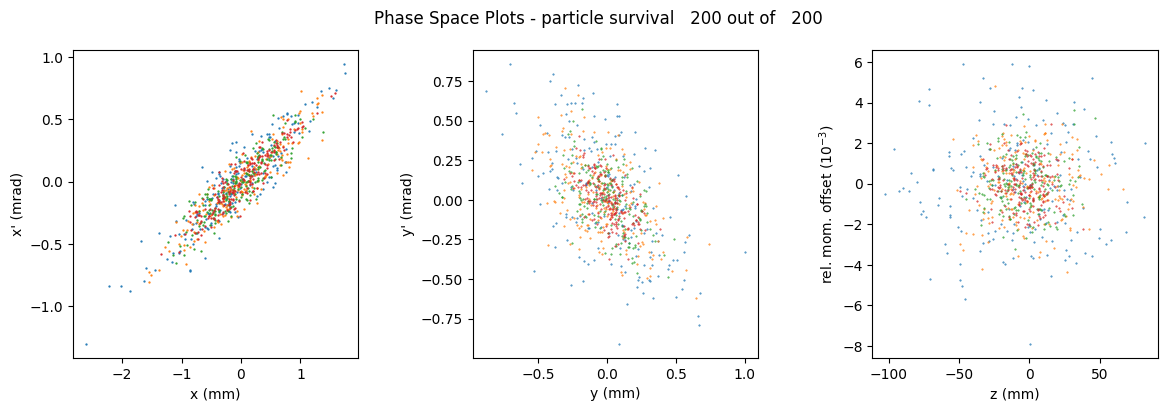

In [26]:
# %% Simple test of tracking with synchrotron radiation - takes some time
ring.configure_radiation(model='mean')
ring_tw=ring.twiss(method='6d', radiation_integrals=True, eneloss_and_damping=True)
#ring_tw.plot()
#print( ring_tw.keys() )
print( f' Energy loss per turn from twiss {ring_tw.eneloss_turn:10.2f} and me {U0:10.2f}')
print( 1/ring_tw.damping_constants_turns )
print( 2*E0/ring_tw.eneloss_turn )

npts = 200
epsx, epsy, epsl = 1.0e-7, 1.0e-7, 1.0e-4  # starting with somewhat large emittances
betxin, alfxin  = ring_tw.betx[0], ring_tw.alfx[0] 
xin, pxin       = ring_tw.x[0], ring_tw.px[0]
dxin, dpxin     = ring_tw.dx[0], ring_tw.dpx[0]
betyin, alfyin  = ring_tw.bety[0], ring_tw.alfy[0] 
yin, pyin       = ring_tw.y[0], ring_tw.py[0]   # should be zero for perfect case
#epsx, epsl      = 2.0*ring_tw.eq_gemitt_x, 2.0*ring_tw.eq_gemitt_zeta
betlin          = ring_tw.bets0
zetain, deltain = ring_tw.zeta[0], ring_tw.delta[0]
print( f'At reference location: D ={dxin:7.4f} m, Dp ={dpxin:7.4f},' +
       f' betx ={betxin:7.4f} m, alfx ={alfxin:7.4f},' + 
       f' betl ={betlin:7.4f} m ')

normat = np.array([
    [(epsx*betxin)**.5,         0,                 0,  0, 0, dxin*(epsl/betlin)**.5],
    [-alfxin*(epsx/betxin)**.5, (epsx/betxin)**.5, 0,  0, 0, dpxin*(epsl/betlin)**.5],
    [0,  0,  (epsx*betyin)**.5,         0,                 0, 0],
    [0,  0,  -alfyin*(epsx/betyin)**.5, (epsx/betyin)**.5, 0, 0],
    [0, 0, 0, 0, (epsl*betlin)**.5, 0                ],
    [0, 0, 0, 0, 0,                 (epsl/betlin)**.5]               
    ])

parts = np.array([
     [xin, pxin, yin, pyin, zetain, deltain] + normat@np.random.randn(6) 
         for ind in range(npts) ]).T
# quit()
p2 = xt.Particles(kinetic_energy0 = 2860.e6, mass0 = xt.ELECTRON_MASS_EV,
                  x    = parts[0], px   = parts[1],
                  y    = parts[2], py   = parts[3],
                  zeta = parts[4], delta = parts[5] )
ring.configure_radiation(model='quantum')
ring.track( p2, num_turns = 6100, turn_by_turn_monitor = True,
            with_progress = True )

data = ring.record_last_track
trnplt = [1, 2000, 4000, 6000]
#trnplt = range( len(data.x.T) ) # superimpose all turns, rendering is slowish
fig = plt.figure( figsize=(14., 4.) )
fig.suptitle( f'Phase Space Plots - particle survival {int(((p2.state + 1)/2).sum()):5d} out of {npts:5d}' )
ax = fig.subplots(1, 3)
fig.subplots_adjust( wspace=0.4 )
ax[0].set_xlabel('x (mm)')
ax[0].set_ylabel("x' (mrad)")
ax[1].set_xlabel('y (mm)')
ax[1].set_ylabel("y' (mrad)")
ax[2].set_xlabel('z (mm)')
ax[2].set_ylabel(r'rel. mom. offset ($10^{-3}$)')
for ind in range( len(trnplt) ):  # data.x.T[ind] is nparray (behaviour of multiplication)!
   print( f' ==> Plotting turn"{trnplt[ind]:5d}')
   ax[0].scatter( 1000*(data.x.T[trnplt[ind]] - 1.*ring_tw.dx[0]*data.delta.T[trnplt[ind]]), 
            1000*(data.px.T[trnplt[ind]] - 1.*ring_tw.dpx[0]*data.delta.T[trnplt[ind]]),
            s=.4, c = f'C{ind:1d}')
   ax[1].scatter( 1000*(data.y.T[trnplt[ind]]), 1000*(data.py.T[trnplt[ind]]), 
            s=.2, c = f'C{ind:1d}' )
   ax[2].scatter(1000*data.zeta.T[trnplt[ind]], 1000*data.delta.T[trnplt[ind]], 
            s=.2, color=f'C{ind:1d}' )

print( [pdr['RFCav_1'].lag, pdr['RFCav_1'].voltage] )

print( f' Particle survival: {int(((p2.state + 1)/2).sum()):5d} out of {npts:5d}' )

### Next Steps ###

* Add sextupoles for chromaticity correction

* Balance between fixing chromaticity and not limiting dynamic aperture